# Systems Genetics 2026 – Final Project

Pipeline: QTL analysis (Section 2) → eQTL analysis (Section 3) → QTL/eQTL overlap (Section 4) → causality / mediation tests (Section 5).

All theoretical answers and discussion are in the report; this notebook contains code and results only.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f as f_dist, linregress

GENOTYPES_FILE = 'genotypes.xls'
PHENOTYPES_FILE = 'phenotypes.xls'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Chosen phenotypes (Section 1).
# 881  = dorsal striatum volume adjusted for shrinkage, age, sex, plane of section and BXD epoch (Rosen et al. 2009);
# 1231 = morphine-induced locomotion, 0-180 min total, females (Philip et al. 2010).
PHENOTYPE_IDS = [881, 1231]

# Genotype encoding for the additive linear-regression model (heterozygotes considered)
GENOTYPE_ENCODING = {'B': 0.0, 'H': 1.0, 'D': 2.0}   # 'U' (unknown) -> NaN
FDR_ALPHA = 0.05          # BH-FDR significance level on q-values
MIN_STRAINS_PER_SNP = 8   # skip SNPs with fewer informative strains
N_FALLBACK_SNPS = 15      # if no significant SNP: report the 15 lowest P-values

## Section 2 – QTL analysis

The pipeline is the HW2 pipeline reduced to its essentials:

1. parse the genotype / phenotype Excel files;
2. for a phenotype ID, regress the strain means on each SNP (encoded B=0, H=1, D=2) and compute the F-test P-value of the regression;
3. correct for multiple testing with Benjamini–Hochberg FDR (q-value per SNP);
4. write a CSV with the significant SNPs (locus name + adjusted P-value), or the 15 lowest-P SNPs if none is significant.

The per-SNP F-test is vectorised over all SNPs with NumPy (sufficient statistics of the simple linear regression), which is also what Section 3 needs when the same test is run for thousands of genes.

### Parsing

In [2]:
def load_genotypes(path=GENOTYPES_FILE):
    """Genotype table: one row per SNP with Locus / Chr / Position + one column per BXD strain (B/D/H/U)."""
    genotype_table = pd.read_excel(path, header=1)
    strain_columns = [c for c in genotype_table.columns if str(c).startswith('BXD')]
    # a handful of calls are lower-case in the file -> normalise
    genotype_table[strain_columns] = genotype_table[strain_columns].apply(lambda calls: calls.str.upper())
    genotype_table = genotype_table.rename(columns={'Chr_Build37': 'Chr', 'Build37_position': 'Position'})
    return genotype_table[['Locus', 'Chr', 'Position'] + strain_columns], strain_columns


def load_phenotypes(path=PHENOTYPES_FILE):
    """Phenotype table: one row per phenotype (ID_FOR_CHECK), one column per strain (strain means)."""
    return pd.read_excel(path)


def encode_genotypes(genotype_table, strain_columns):
    """Numeric SNP x strain matrix, B=0 / H=1 / D=2, NaN for unknown calls."""
    encoded = genotype_table[strain_columns].apply(lambda calls: calls.map(GENOTYPE_ENCODING))   # unmapped ('U') -> NaN
    return encoded.to_numpy(dtype=float)


def get_phenotype_vector(phenotype_table, phenotype_id, strain_columns):
    """Strain means of one phenotype, aligned to `strain_columns` (NaN where the strain was not measured)."""
    rows = phenotype_table.loc[phenotype_table['ID_FOR_CHECK'] == phenotype_id]
    if rows.empty:
        raise KeyError(f'phenotype {phenotype_id} not found')
    row = rows.iloc[0]
    values = pd.to_numeric(row.reindex(strain_columns), errors='coerce').to_numpy(dtype=float)
    return values, row['Phenotype']


genotypes, STRAINS = load_genotypes()
phenotypes = load_phenotypes()
STRAINS = [strain for strain in STRAINS if strain in phenotypes.columns]      # strains present in both files
GENOTYPE_MATRIX = encode_genotypes(genotypes, STRAINS)                        # SNPs x strains, 0/1/2/NaN

print(f'{len(genotypes)} SNPs x {len(STRAINS)} BXD strains; {len(phenotypes)} phenotypes')
print('unknown genotype calls:', f'{np.isnan(GENOTYPE_MATRIX).mean():.1%}')
genotypes.head(3)

3796 SNPs x 92 BXD strains; 2885 phenotypes
unknown genotype calls: 3.3%


,Locus,Chr,Position,BXD1,BXD2,BXD5,BXD6,BXD8,BXD9,BXD11,...,BXD94,BXD95,BXD96,BXD97,BXD98,BXD99,BXD100,BXD101,BXD102,BXD103
0,rs6269442,1,3482276,B,B,D,D,D,B,B,...,D,D,B,B,B,B,B,U,U,U
1,rs6365999,1,4811063,B,B,D,D,D,B,B,...,D,D,B,B,B,B,B,U,U,U
2,rs6376963,1,5008090,B,B,D,D,D,B,B,...,D,D,B,B,B,B,B,U,U,U


### Association test (F-test of the linear regression) and BH-FDR

In [3]:
def f_test_all_snps(genotype_matrix, trait, min_n=MIN_STRAINS_PER_SNP):
    """F-test of the simple linear regression trait ~ b0 + b1 * genotype, for every SNP at once.

    genotype_matrix : (n_snps, n_strains) numeric genotypes (0/1/2, NaN = unknown)
    trait           : (n_strains,) trait values (NaN = strain not measured)
    Returns (p_values, n_strains_used); NaN P-value for SNPs that are monomorphic in the measured strains
    or have fewer than `min_n` informative strains.
    F = (SS_regression / 1) / (SS_residual / (n - 2)),  F ~ F(1, n-2) under H0: b1 = 0.
    """
    measured = ~np.isnan(trait)
    genotype_matrix, trait = genotype_matrix[:, measured], trait[measured]
    known = ~np.isnan(genotype_matrix)
    x = np.where(known, genotype_matrix, 0.0)
    y = np.where(known, trait, 0.0)               # trait masked per SNP by its known genotypes
    n = known.sum(axis=1)
    sum_x, sum_y = x.sum(axis=1), y.sum(axis=1)
    sum_xx, sum_yy, sum_xy = (x * x).sum(axis=1), (y * y).sum(axis=1), (x * y).sum(axis=1)
    with np.errstate(invalid='ignore', divide='ignore'):
        ss_x = sum_xx - sum_x ** 2 / n            # centred sums of squares / cross-products
        ss_y = sum_yy - sum_y ** 2 / n
        ss_xy = sum_xy - sum_x * sum_y / n
        ss_regression = ss_xy ** 2 / ss_x
        ss_residual = ss_y - ss_regression
        f_statistic = ss_regression / (ss_residual / (n - 2))
        p_values = f_dist.sf(f_statistic, 1, n - 2)
    p_values[(n < min_n) | ~(ss_x > 0)] = np.nan
    return p_values, n


def bh_fdr(p_values):
    """Benjamini-Hochberg adjusted P-values (q-values). NaNs are ignored and returned as NaN."""
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full_like(p_values, np.nan)
    valid = ~np.isnan(p_values)
    valid_p = p_values[valid]
    n_tests = valid_p.size
    order = np.argsort(valid_p)
    adjusted = valid_p[order] * n_tests / np.arange(1, n_tests + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]   # enforce monotonicity
    valid_q = np.empty(n_tests)
    valid_q[order] = np.minimum(adjusted, 1.0)
    q_values[valid] = valid_q
    return q_values


# sanity check: the vectorised F-test equals scipy's per-SNP regression P-value
check_trait, _ = get_phenotype_vector(phenotypes, PHENOTYPE_IDS[0], STRAINS)
check_p_values, _ = f_test_all_snps(GENOTYPE_MATRIX, check_trait)
for snp_index in [0, 500, 1500, 3000]:
    informative = ~np.isnan(GENOTYPE_MATRIX[snp_index]) & ~np.isnan(check_trait)
    scipy_p = linregress(GENOTYPE_MATRIX[snp_index][informative], check_trait[informative]).pvalue
    assert np.isclose(check_p_values[snp_index], scipy_p)
print('vectorised F-test matches scipy.stats.linregress')

vectorised F-test matches scipy.stats.linregress


### QTL pipeline

In [4]:
def run_qtl_pipeline(phenotype_id, alpha=FDR_ALPHA):
    """Full QTL scan for one phenotype. Returns a DataFrame (one row per SNP) sorted by P-value,
    and writes the significant SNPs (or the 15 lowest-P SNPs) to results/qtl_<id>.csv."""
    trait, trait_name = get_phenotype_vector(phenotypes, phenotype_id, STRAINS)
    p_values, n_strains = f_test_all_snps(GENOTYPE_MATRIX, trait)
    results = genotypes[['Locus', 'Chr', 'Position']].copy()
    results['n_strains'] = n_strains
    results['p_value'] = p_values
    results['q_value'] = bh_fdr(p_values)
    results['significant'] = results['q_value'] < alpha
    results = results.sort_values('p_value').reset_index(drop=True)

    n_significant = int(results['significant'].sum())
    reported = results[results['significant']] if n_significant > 0 else results.head(N_FALLBACK_SNPS)
    reported[['Locus', 'q_value']].rename(columns={'q_value': 'adjusted_p_value'}).to_csv(
        f'{RESULTS_DIR}/qtl_{phenotype_id}.csv', index=False)

    print(f'Phenotype {phenotype_id}: {trait_name.strip()}')
    print(f'  strains measured: {int((~np.isnan(trait)).sum())}  |  SNPs tested: {int(results.p_value.notna().sum())}')
    print(f'  significant SNPs (q < {alpha}): {n_significant}'
          + ('' if n_significant else f'  -> reporting {N_FALLBACK_SNPS} lowest P-values'))
    if n_significant:
        print('  significant SNPs per chromosome:', results[results.significant].groupby('Chr').size().to_dict())
    return results

### QTL scan of the two chosen phenotypes

In [5]:
qtl_results = {phenotype_id: run_qtl_pipeline(phenotype_id) for phenotype_id in PHENOTYPE_IDS}

Phenotype 881: Central nervous system, morphology: Striatum volume, dorsal striatum, bilateral and adjusted for shrinkage, age, sex, plane of section, and BXD group/epoch (mm^3)
  strains measured: 53  |  SNPs tested: 3796
  significant SNPs (q < 0.05): 24
  significant SNPs per chromosome: {6: 24}
Phenotype 1231: Morphine response (50 mg/kg ip), locomotion from 0-180 min (total activity over 3 hour test) after injection in an activity chamber for females [cm]
  strains measured: 64  |  SNPs tested: 3796
  significant SNPs (q < 0.05): 38
  significant SNPs per chromosome: {5: 7, 10: 25, 11: 6}


In [6]:
# Significant SNPs (or 15 lowest P) per phenotype - the content of results/qtl_<id>.csv
for phenotype_id, results in qtl_results.items():
    reported = results[results.significant] if results.significant.any() else results.head(N_FALLBACK_SNPS)
    print(f'\n=== Phenotype {phenotype_id}: {len(reported)} SNPs written to {RESULTS_DIR}/qtl_{phenotype_id}.csv ===')
    display(reported[['Locus', 'Chr', 'Position', 'n_strains', 'p_value', 'q_value']].reset_index(drop=True))


=== Phenotype 881: 24 SNPs written to results/qtl_881.csv ===


,Locus,Chr,Position,n_strains,p_value,q_value
0,rs13478889,6,91386029,53,0.000015,0.012110
1,rs3661039,6,90308024,53,0.000015,0.012110
2,rs13478880,6,88537081,53,0.000018,0.012110
3,rs3713705,6,88668211,53,0.000018,0.012110
4,rs4226061,6,86579760,53,0.000019,0.012110
5,rs13475374,6,86953033,53,0.000019,0.012110
6,rs13478871,6,85767550,53,0.000028,0.013520
7,CEL-6_86437630,6,86058923,53,0.000028,0.013520
8,gnf06.086.089,6,87099761,53,0.000036,0.013841
9,rs13478876,6,87384144,53,0.000036,0.013841



=== Phenotype 1231: 38 SNPs written to results/qtl_1231.csv ===


,Locus,Chr,Position,n_strains,p_value,q_value
0,rs13480484,10,8189404,64,0.000002,0.001804
1,rs4228079,10,4609418,64,0.000002,0.001804
2,rs3721803,10,3342586,64,0.000002,0.001804
3,rs3695003,10,7632997,64,0.000002,0.001804
4,D10Mit28,10,9133173,64,0.000003,0.002063
5,rs6185923,10,5378623,64,0.000003,0.002063
6,rs13481187,11,100513550,64,0.000023,0.011003
7,rs13481186,11,100224674,64,0.000023,0.011003
8,rs3664101,10,9329071,64,0.000094,0.025832
9,rs4139678,10,12004986,64,0.000094,0.025832


## Section 3 – eQTL analysis

### 3.1 Preprocessing of the expression data

Steps (a)–(h) of the assignment, applied identically to both tissues. The normalised values deposited in GEO are used as-is
(hypothalamus: RMA log2 intensities; liver: LOWESS-normalised log2 ratios). Because the two platforms are on different scales,
the thresholds of steps (d) and (e) are defined as percentiles of each dataset's own distribution (histograms below).
Gene positions of the hypothalamus platform are annotated on GRCm38 (mm10) and are lifted over to NCBI Build 37 (mm9),
the build of the genotype file and of the liver platform.

In [7]:
import urllib.request
import GEOparse
from pyliftover import LiftOver

GEO_DIR = 'data/geo'
TISSUES = {'hypothalamus': 'GSE36674', 'liver': 'GSE17522'}
MAX_QUANTILE = 0.10   # (d) drop probes whose maximal value is in the lowest 10% of the dataset
VAR_QUANTILE = 0.10   # (e) drop probes whose variance is in the lowest 10% of the remaining probes
CHAIN_URL = 'https://hgdownload.soe.ucsc.edu/goldenPath/mm10/liftOver/mm10ToMm9.over.chain.gz'
CHAIN_FILE = 'data/liftover/mm10ToMm9.over.chain.gz'
X_CHROMOSOME = 20     # chromosome number used for X in the genotype file


def download_geo(accession):
    """(a) Download (or load the cached copy of) a GEO series with its platform annotation."""
    os.makedirs(GEO_DIR, exist_ok=True)
    return GEOparse.get_GEO(accession, destdir=GEO_DIR, silent=True)


geo_series = {tissue: download_geo(accession) for tissue, accession in TISSUES.items()}
for tissue, series in geo_series.items():
    print(f"{tissue}: {TISSUES[tissue]} - {series.metadata['title'][0]} | platform {list(series.gpls)[0]} | {len(series.gsms)} arrays")

hypothalamus: GSE36674 - Expression data for mouse hypothalamus | platform GPL6246 | 89 arrays
liver: GSE17522 - BXD Mouse Liver Gene Expression | platform GPL6466 | 122 arrays


#### Parsing: expression matrix and platform annotation

In [8]:
def expression_matrix(series):
    """Probes x arrays matrix of the deposited normalised VALUEs, plus the strain of every array
    (taken from the 'strain: ...' field of the sample characteristics)."""
    values_per_array, strain_per_array = {}, {}
    for array_id, sample in series.gsms.items():
        characteristics = dict(entry.split(': ', 1) for entry in sample.metadata['characteristics_ch1'])
        strain_per_array[array_id] = characteristics['strain']
        values_per_array[array_id] = sample.table.set_index('ID_REF')['VALUE']
    expression = pd.DataFrame(values_per_array)
    expression.index = expression.index.astype(str)
    return expression, pd.Series(strain_per_array)


def chromosome_number(name):
    """'chr5' -> 5, 'chrX' -> 20 (as in the genotype file); NaN for unplaced contigs, Y and M."""
    name = str(name).replace('chr', '')
    if name == 'X':
        return X_CHROMOSOME
    return int(name) if name.isdigit() else np.nan


def annotate_gpl6246(platform_table):
    """Affymetrix MoGene 1.0 ST (hypothalamus). Only 'main' transcript clusters are genes (the rest are controls).
    Gene symbol = 2nd field of the primary gene_assignment entry ('RefSeq // Symbol // name // cytoband // Entrez /// ...').
    Position = transcript-cluster start (GRCm38)."""
    clusters = platform_table[platform_table['category'] == 'main'].set_index('ID')

    def primary_symbol(gene_assignment):
        if not isinstance(gene_assignment, str):
            return None
        fields = [field.strip() for field in gene_assignment.split('///')[0].split('//')]
        return fields[1] if len(fields) > 1 and fields[1] not in ('', '---') else None

    annotation = pd.DataFrame({'symbol': clusters['gene_assignment'].map(primary_symbol),
                               'chr': clusters['seqname'].map(chromosome_number),
                               'pos': pd.to_numeric(clusters['RANGE_START'], errors='coerce')})
    annotation.index = annotation.index.astype(str)
    return annotation


def annotate_gpl6466(platform_table):
    """Agilent G4121A (liver). Non-control probes only; GENE_SYMBOL column; position = probe location 'chrN:start-end' (mm9)."""
    probes = platform_table[platform_table['CONTROL_TYPE'] == 'FALSE'].set_index('ID')
    location = probes['CHROMOSOMAL_LOCATION'].str.extract(r'^(chr[0-9XY]+):(\d+)-')
    annotation = pd.DataFrame({'symbol': probes['GENE_SYMBOL'],
                               'chr': location[0].map(chromosome_number),
                               'pos': pd.to_numeric(location[1], errors='coerce')})
    annotation.index = annotation.index.astype(str)
    return annotation


def liftover_mm10_to_mm9(annotation):
    """Convert GRCm38 positions to NCBI Build 37 with the UCSC chain file. Positions that do not map
    (or map to another chromosome) become NaN."""
    os.makedirs(os.path.dirname(CHAIN_FILE), exist_ok=True)
    if not os.path.exists(CHAIN_FILE):
        urllib.request.urlretrieve(CHAIN_URL, CHAIN_FILE)
    lifter = LiftOver(CHAIN_FILE)

    def convert(chromosome, position):
        if np.isnan(chromosome) or np.isnan(position):
            return np.nan
        chromosome_name = 'chrX' if chromosome == X_CHROMOSOME else f'chr{int(chromosome)}'
        hits = lifter.convert_coordinate(chromosome_name, int(position))
        return hits[0][1] if hits and chromosome_number(hits[0][0]) == chromosome else np.nan

    lifted = annotation.copy()
    lifted['pos'] = [convert(chromosome, position) for chromosome, position in zip(annotation['chr'], annotation['pos'])]
    return lifted


ANNOTATORS = {'hypothalamus': annotate_gpl6246, 'liver': annotate_gpl6466}

#### Preprocessing steps (b)–(h)

In [9]:
def keep_genotyped_strains(expression, strain_per_array):
    """(b) Keep only arrays of BXD strains that are present in the genotype file."""
    genotyped_arrays = strain_per_array[strain_per_array.isin(STRAINS)]
    return expression[genotyped_arrays.index], genotyped_arrays


def drop_without_symbol(expression, annotation):
    """(c) Remove probes that have no gene identifier."""
    has_symbol = annotation.loc[expression.index, 'symbol'].notna()
    return expression[has_symbol]


def drop_low_max(expression, quantile):
    """(d) Remove probes whose maximal value is below the given quantile of the per-probe maxima."""
    max_per_probe = expression.max(axis=1)
    threshold = max_per_probe.quantile(quantile)
    return expression[max_per_probe >= threshold], max_per_probe, threshold


def drop_low_variance(expression, quantile):
    """(e) Remove probes whose variance is below the given quantile of the per-probe variances."""
    variance_per_probe = expression.var(axis=1)
    threshold = variance_per_probe.quantile(quantile)
    return expression[variance_per_probe >= threshold], variance_per_probe, threshold


def one_probe_per_gene(expression, annotation):
    """(f) Keep the highest-variance probe of every gene; rows are re-indexed by gene symbol."""
    symbol_per_probe = annotation.loc[expression.index, 'symbol']
    best_probe_per_gene = expression.var(axis=1).groupby(symbol_per_probe).idxmax()
    gene_expression = expression.loc[best_probe_per_gene.values].set_index(best_probe_per_gene.index)
    gene_annotation = annotation.loc[best_probe_per_gene.values].set_index(best_probe_per_gene.index)
    return gene_expression, gene_annotation


def average_per_strain(expression, strain_per_array):
    """(h) Average the arrays of the same strain -> genes x strains matrix of strain means."""
    return expression.T.groupby(strain_per_array).mean().T


def representative_snps(strains):
    """(g) Genotypes restricted to `strains` (genome order). Consecutive SNPs carrying identical genotypes across
    these strains (unknown calls 'U' included in the comparison) give identical association results; each such run is
    represented by its first SNP, and the run's genomic span (RunStart-RunEnd) and size are recorded.
    Returns the SNP table, the encoded SNP x strain matrix and the strain order."""
    strain_columns = [strain for strain in STRAINS if strain in set(strains)]
    ordered = genotypes.sort_values(['Chr', 'Position']).reset_index(drop=True)
    calls = ordered[strain_columns].fillna('U').to_numpy(dtype=str)
    same_chromosome = ordered['Chr'].to_numpy()[1:] == ordered['Chr'].to_numpy()[:-1]
    same_as_previous = (calls[1:] == calls[:-1]).all(axis=1) & same_chromosome
    is_representative = np.concatenate([[True], ~same_as_previous])
    run_id = np.cumsum(is_representative)
    runs = ordered.groupby(run_id)['Position'].agg(RunStart='min', RunEnd='max', RunSize='size')
    snp_table = ordered.loc[is_representative, ['Locus', 'Chr', 'Position']].reset_index(drop=True)
    snp_table = pd.concat([snp_table, runs.reset_index(drop=True)], axis=1)
    return snp_table, encode_genotypes(ordered.loc[is_representative], strain_columns), strain_columns

hypothalamus: 34760 probes x 89 arrays; strains not in the genotype file (dropped): ['B6D2', 'BXD92A', 'C57BL/6J', 'D2B6F1', 'DBA/2J']
  thresholds: max value >= 6.104 (10% quantile), variance >= 0.0089 (10% quantile)
liver: 20868 probes x 122 arrays; strains not in the genotype file (dropped): ['B6D2F1', 'BXD11TY', 'C57BL6J', 'DBA2J']


  thresholds: max value >= -0.683 (10% quantile), variance >= 0.0210 (10% quantile)


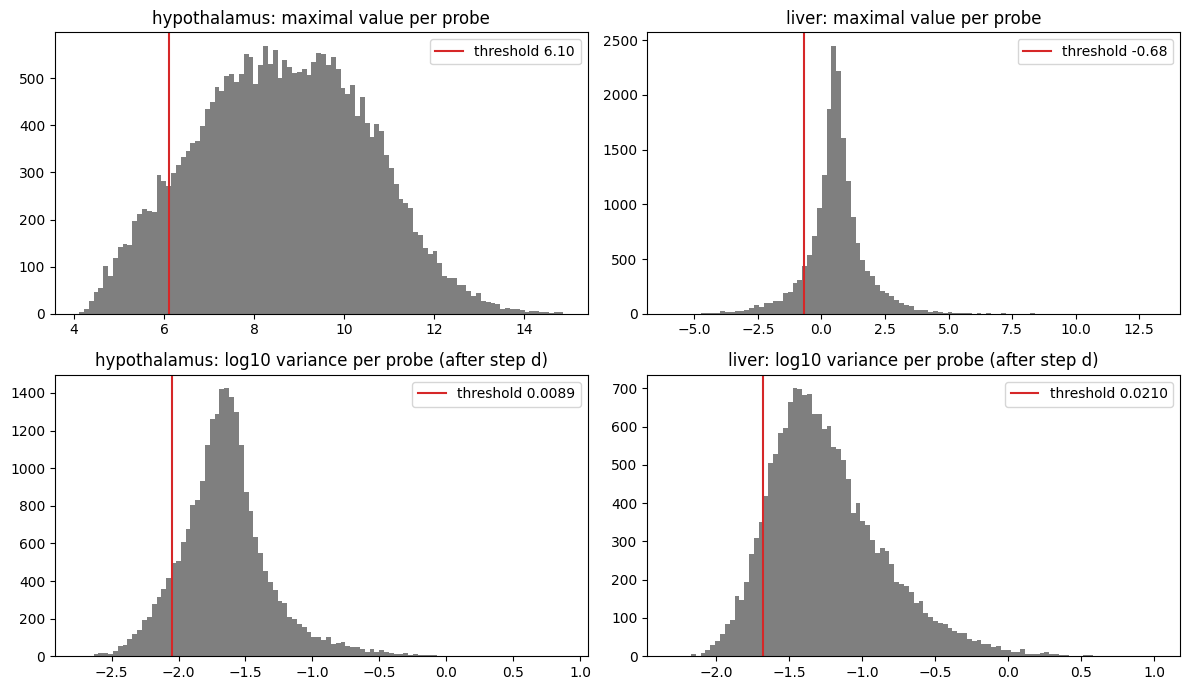

hypothalamus: 1598 representative SNPs; run size median 2 (max 12), run span median 0.38 Mb (max 10.0 Mb)
liver: 1403 representative SNPs; run size median 2 (max 14), run span median 0.47 Mb (max 10.3 Mb)


,hypothalamus,liver
annotated probes,28101,20868
(b) arrays of genotyped BXD strains,79,79
(c) probes with gene symbol,26710,19272
(d) probes with max >= threshold,24042,17348
(e) probes with variance >= threshold,21637,15613
(f) genes (one probe each),19577,14659
(f) genes with a genomic position,19453,14579
(h) strains after averaging,45,40
(g) representative SNPs,1598,1403


In [10]:
expression = {}          # tissue -> genes x strains matrix of strain means
gene_annotation = {}     # tissue -> symbol / chr / pos (mm9) per gene
snp_table = {}           # tissue -> representative SNPs (Locus, Chr, Position)
snp_matrix = {}          # tissue -> encoded representative SNPs x strains
step_counts = {}         # tissue -> number of rows after each preprocessing step

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for column, tissue in enumerate(TISSUES):
    series = geo_series[tissue]
    probes, strain_per_array = expression_matrix(series)
    annotation = ANNOTATORS[tissue](series.gpls[list(series.gpls)[0]].table)
    if tissue == 'hypothalamus':
        annotation = liftover_mm10_to_mm9(annotation)
    print(f'{tissue}: {probes.shape[0]} probes x {probes.shape[1]} arrays; strains not in the genotype file (dropped): '
          f'{sorted(set(strain_per_array) - set(STRAINS))}')

    counts = {}
    probes = probes.loc[probes.index.intersection(annotation.index)]
    counts['annotated probes'] = len(probes)
    probes, strain_per_array = keep_genotyped_strains(probes, strain_per_array)
    counts['(b) arrays of genotyped BXD strains'] = probes.shape[1]
    probes = drop_without_symbol(probes, annotation)
    counts['(c) probes with gene symbol'] = len(probes)
    probes, max_per_probe, max_threshold = drop_low_max(probes, MAX_QUANTILE)
    counts['(d) probes with max >= threshold'] = len(probes)
    probes, variance_per_probe, variance_threshold = drop_low_variance(probes, VAR_QUANTILE)
    counts['(e) probes with variance >= threshold'] = len(probes)
    genes, gene_annotation[tissue] = one_probe_per_gene(probes, annotation)
    counts['(f) genes (one probe each)'] = len(genes)
    counts['(f) genes with a genomic position'] = int(gene_annotation[tissue]['pos'].notna().sum())
    strain_means = average_per_strain(genes, strain_per_array)
    counts['(h) strains after averaging'] = strain_means.shape[1]
    snp_table[tissue], snp_matrix[tissue], strain_order = representative_snps(strain_means.columns)
    counts['(g) representative SNPs'] = len(snp_table[tissue])
    expression[tissue] = strain_means[strain_order]
    step_counts[tissue] = counts
    print(f'  thresholds: max value >= {max_threshold:.3f} ({MAX_QUANTILE:.0%} quantile), '
          f'variance >= {variance_threshold:.4f} ({VAR_QUANTILE:.0%} quantile)')

    axes[0, column].hist(max_per_probe, bins=100, color='C7')
    axes[0, column].axvline(max_threshold, color='C3', label=f'threshold {max_threshold:.2f}')
    axes[0, column].set_title(f'{tissue}: maximal value per probe'); axes[0, column].legend()
    axes[1, column].hist(np.log10(variance_per_probe), bins=100, color='C7')
    axes[1, column].axvline(np.log10(variance_threshold), color='C3', label=f'threshold {variance_threshold:.4f}')
    axes[1, column].set_title(f'{tissue}: log10 variance per probe (after step d)'); axes[1, column].legend()
plt.tight_layout(); plt.show()

for tissue in TISSUES:
    runs = snp_table[tissue]
    print(f'{tissue}: {len(runs)} representative SNPs; run size median {runs.RunSize.median():.0f} (max {runs.RunSize.max()}), '
          f'run span median {(runs.RunEnd - runs.RunStart).median() / 1e6:.2f} Mb (max {(runs.RunEnd - runs.RunStart).max() / 1e6:.1f} Mb)')
pd.DataFrame(step_counts)

### 3.2 eQTL association test

Every gene is tested against every representative SNP with the same regression F-test as in Section 2
(expression strain means as the trait; B=0, H=1, D=2). BH-FDR is applied once over all gene × SNP tests of a tissue.
For each gene the best-associated SNP (lowest P) is its eQTL, kept only if its q-value is below `FDR_ALPHA`;
genes whose best association is not significant are excluded.

In [11]:
def eqtl_scan(strain_means, snp_matrix, snp_loci):
    """F-test P-value of every gene x SNP pair. Returns a genes x SNPs DataFrame."""
    p_values = np.vstack([f_test_all_snps(snp_matrix, gene_values)[0] for gene_values in strain_means.to_numpy()])
    return pd.DataFrame(p_values, index=strain_means.index, columns=snp_loci)


def select_eqtls(p_values, q_values, snp_table, annotation, alpha=FDR_ALPHA):
    """One row per gene: its best-associated SNP (lowest P) with the SNP's position and run span, the gene's position,
    P and q. Only genes whose best SNP is significant (q < alpha) are returned."""
    best_snp_index = np.nanargmin(p_values.to_numpy(), axis=1)
    genes = np.arange(len(p_values))
    eqtls = pd.DataFrame({
        'gene': p_values.index,
        'gene_chr': annotation.loc[p_values.index, 'chr'].to_numpy(),
        'gene_pos': annotation.loc[p_values.index, 'pos'].to_numpy(),
        'snp': snp_table['Locus'].to_numpy()[best_snp_index],
        'snp_chr': snp_table['Chr'].to_numpy()[best_snp_index],
        'snp_pos': snp_table['Position'].to_numpy()[best_snp_index],
        'run_start': snp_table['RunStart'].to_numpy()[best_snp_index],
        'run_end': snp_table['RunEnd'].to_numpy()[best_snp_index],
        'p_value': p_values.to_numpy()[genes, best_snp_index],
        'q_value': q_values.to_numpy()[genes, best_snp_index],
    })
    return eqtls[eqtls['q_value'] < alpha].sort_values('p_value').reset_index(drop=True)


eqtl_p_values, eqtl_q_values, eqtls = {}, {}, {}
for tissue in TISSUES:
    p_values = eqtl_scan(expression[tissue], snp_matrix[tissue], snp_table[tissue]['Locus'])
    q_values = pd.DataFrame(bh_fdr(p_values.to_numpy().ravel()).reshape(p_values.shape),
                            index=p_values.index, columns=p_values.columns)
    eqtl_p_values[tissue], eqtl_q_values[tissue] = p_values, q_values
    eqtls[tissue] = select_eqtls(p_values, q_values, snp_table[tissue], gene_annotation[tissue])
    eqtls[tissue].to_csv(f'{RESULTS_DIR}/eqtl_{tissue}.csv', index=False)
    n_tests = int(p_values.notna().sum().sum())
    print(f'{tissue}: {p_values.shape[0]} genes x {p_values.shape[1]} SNPs = {n_tests:,} tests | '
          f'gene x SNP pairs with q < {FDR_ALPHA}: {int((q_values < FDR_ALPHA).sum().sum()):,} | '
          f'genes with a significant eQTL: {len(eqtls[tissue]):,} | distinct eQTL SNPs: {eqtls[tissue].snp.nunique():,}')

eqtls['hypothalamus'].head(10)

hypothalamus: 19577 genes x 1598 SNPs = 31,284,046 tests | gene x SNP pairs with q < 0.05: 7,509 | genes with a significant eQTL: 1,416 | distinct eQTL SNPs: 610


liver: 14659 genes x 1403 SNPs = 20,566,577 tests | gene x SNP pairs with q < 0.05: 6,804 | genes with a significant eQTL: 1,285 | distinct eQTL SNPs: 572


,gene,gene_chr,gene_pos,snp,snp_chr,snp_pos,run_start,run_end,p_value,q_value
0,Hspa8,9.0,40609356.0,rs6240566,9,40268402,40268402,40515147,3.201308e-30,5.455211e-23
1,Gm22289,7.0,67049641.0,rs13479276,7,65717523,65717523,66413236,3.487536e-30,5.455211e-23
2,Rpl3,15.0,79908225.0,rs3667755,15,78741347,78741347,81745213,6.264050e-30,6.532161e-23
3,Hdhd3,4.0,62160046.0,rs13477735,4,61518987,61518987,61518987,6.761728e-29,5.288355e-22
4,Gm26337,7.0,66678425.0,rs13479276,7,65717523,65717523,66413236,4.551343e-27,2.847688e-20
5,Pttg1,11.0,43233764.0,D11Mit20,11,44552713,44552713,46029522,1.120278e-26,5.841137e-20
6,Dlg4,11.0,69830717.0,rs13481087,11,69415411,69415411,70265537,2.933592e-26,1.311066e-19
7,Alad,4.0,62170202.0,rs13477735,4,61518987,61518987,61518987,4.309699e-26,1.685310e-19
8,Aldh7a1,18.0,56685390.0,CEL-18_56957668,18,56618687,56618687,56763124,1.468643e-25,4.259439e-19
9,Sat2,11.0,69435554.0,rs13481087,11,69415411,69415411,70265537,1.478025e-25,4.259439e-19


## Section 4 – Combining QTL and eQTL results
*(to do)*

## Section 5 – Causality analysis
*(to do)*